# Pipeline with Reconstruction using ScanNet Scenes

Same end-to-end flow as `Pipeline3D_ScanNet.ipynb`, but geometry comes from
**VGGT-Omega** (RGB-only) instead of ScanNet ground-truth depth/poses.
Everything downstream (`Indexer`, `Search2D`, `ProjectTo3D`,
`build_scene_cloud`, k3d) is unchanged.

1. **Reconstruction** — RGB frames from `SCENE_DIR/color/` →
   `VGGTOmegaReconstructor.reconstruct(...)` → `FrameSet`.
2. **Index** — `FrameSet` → `Indexer.insert(...)`.
3. **Query** — `embed | retrieve | select | detect | rerank | project`, in one
   of two retrieval modes:
   - **`topk`** — legacy fixed-k: exactly `TOP_K_RETRIEVE` frames go to SAM.
   - **`dynamic`** — Otsu-sized pool over *all* frames + `SelectDiverse` picks
     `n_diverse` viewpoint-diverse frames for SAM.
4. **Visualise** — k3d: scene cloud + fused object (red) + 3D box.

## ScanNet layout (RGB only)

Point `SCENE_DIR` at a ScanNet export. This notebook **only reads**
`color/{i}.jpg` — depth, poses, and intrinsics are predicted by
`VGGTOmegaReconstructor` (see `models.vggt_omega` in `config.yaml`).

```
SCENE_DIR/
  color/{i}.jpg              # RGB frames used as reconstructor input
```

Reconstruction artefacts (16-bit depth PNGs) are written under
`data/reconstruction/{COLLECTION}/`.

## Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import k3d

# ── ensure project root is on sys.path and is the working directory ──────────
PROJECT_ROOT = Path("__file__").resolve().parent.parent
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = Path("__file__").resolve().parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Project root : {PROJECT_ROOT}")
print(f"Using device : {device}")

Project root : /usr/prakt/s0034/AppliedFoundationModels
Using device : cuda


## Dataset config

In [3]:
# Point this at a downloaded ScanNet scene directory (see the layout cell above).
SCENE_DIR  = "/storage/group/dataset_mirrors/scannet/scans/scene0011_00"

# Distinct from the GT collection used by Pipeline3D_ScanNet.ipynb.
COLLECTION = "scannet_scene0011_00_vggt"

## Reconstruction

Gather RGB paths from `SCENE_DIR/color/` and run
`VGGTOmegaReconstructor` to predict depth, poses, and averaged
intrinsics. Depth maps are written under
`data/reconstruction/{COLLECTION}/`. Knobs live in
`config.yaml → models.vggt_omega` (e.g. `max_frames`,
`confidence_threshold`).

In [4]:
import yaml

from src.reconstruct import VGGTOmegaReconstructor

cfg = yaml.safe_load(Path("config.yaml").read_text())
vggt_cfg = cfg["models"]["vggt_omega"]
max_frames = int(vggt_cfg["max_frames"])

# RGB-only input: natural order by frame index (same convention as ScanNet).
rgb_paths = sorted(
    (str(p) for p in Path(SCENE_DIR).glob("color/*.jpg")),
    key=lambda p: int(Path(p).stem),
)
out_dir = Path("data/reconstruction") / COLLECTION
depth_dir = out_dir / "depth"

print(f"Scene      : {SCENE_DIR}")
print(f"Collection : {COLLECTION}")
print(f"Scene RGB  : {len(rgb_paths):,} frames on disk")
print(
    f"max_frames : {max_frames}  ← models.vggt_omega.max_frames in config.yaml "
    f"(THIS caps how many frames the reconstructor will use)"
)

print("Running VGGT-Omega reconstruction …")
rec = VGGTOmegaReconstructor.from_config("config.yaml")
fs = rec.reconstruct(rgb_paths, out_dir)

n = len(fs)
print(f"Depth dir  : {depth_dir}")
print(
    f"Frames used: {n:,}  "
    f"(predicted depth + cam-to-world pose written/returned per frame)"
)
print(
    f"Intrinsics : {fs.intrinsics}  "
    f"(AVERAGED over the predictions of the {n} frames used)"
)
print(
    f"depth_scale: {fs.depth_scale}  "
    f"← models.vggt_omega.depth_scale in config.yaml "
    + "(ARBITRARY for this pipeline — VGGT-Omega reconstruction is up-to-scale)"
)


Scene      : /storage/group/dataset_mirrors/scannet/scans/scene0011_00
Collection : scannet_scene0011_00_vggt
Scene RGB  : 2,374 frames on disk
max_frames : 120  ← models.vggt_omega.max_frames in config.yaml (THIS caps how many frames the reconstructor will use)
Running VGGT-Omega reconstruction …
Depth dir  : data/reconstruction/scannet_scene0011_00_vggt/depth
Frames used: 120  (predicted depth + cam-to-world pose written/returned per frame)
Intrinsics : {'fx': 542.294677734375, 'fy': 540.844970703125, 'cx': 296.0, 'cy': 224.0}  (AVERAGED over the predictions of the 120 frames used)
depth_scale: 1000.0  ← models.vggt_omega.depth_scale in config.yaml (ARBITRARY for this pipeline — VGGT-Omega reconstruction is up-to-scale)


## Index

Insert the reconstructed `FrameSet` into LanceDB. Skips if
`COLLECTION` already exists (use a new name, or drop the table, to
re-index).

In [5]:
from src.index import Indexer, get_status
from src.utils.db import connect as db_connect
from src.utils.datasets import load_collection
import yaml

cfg = yaml.safe_load(Path("config.yaml").read_text())
db  = db_connect(cfg["indexing"]["db_path"])

print(f"Collection : {COLLECTION}")
print(f"Frames     : {len(fs):,}")
print(f"Intrinsics : {fs.intrinsics}  ·  depth_scale={fs.depth_scale}")

if COLLECTION in db.list_tables().tables:
    n_rows = db.open_table(COLLECTION).count_rows()
    print(f"'{COLLECTION}' already exists with {n_rows:,} rows — skipping indexing.")
    # Prefer the indexed copy so later cells match what retrieval will see.
    fs = load_collection(db, COLLECTION)
    print(f"Loaded indexed FrameSet — {len(fs):,} frames")
else:
    print(f"Indexing '{COLLECTION}' …")
    idx = Indexer.from_config("config.yaml")
    job = idx.insert(
        fs.paths, COLLECTION,
        depth_paths=fs.depth_paths, poses=fs.poses,
        intrinsics=fs.intrinsics, depth_scale=fs.depth_scale,
    )
    status = get_status(job.job_id)
    print(f"Done — {status['processed']}/{status['total']} frames")


Collection : scannet_scene0011_00_vggt
Frames     : 120
Intrinsics : {'fx': 542.294677734375, 'fy': 540.844970703125, 'cx': 296.0, 'cy': 224.0}  ·  depth_scale=1000.0
Indexing 'scannet_scene0011_00_vggt' …


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Indexing 'scannet_scene0011_00_vggt':   0%|          | 0/120 [00:00<?, ?img/s]

Done — 120/120 frames


## Build pipeline (SAM)

In [6]:
from src.query.pipeline import Search2D

pipeline = Search2D.from_config("config.yaml", detector="sam")
print("SAM pipeline ready (chain: embed | retrieve | select | detect | rerank | project).")

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

SAM pipeline ready (chain: embed | retrieve | select | detect | rerank | project).


## Query — mode A: fixed top-k (`topk`, legacy)

Retrieves exactly `TOP_K_RETRIEVE` frames by cosine similarity and runs SAM on
all of them — no thresholding, no diversity selection. Kept as the baseline;
the mode must be passed explicitly since the config default is now `dynamic`
(which ignores `TOP_K_RETRIEVE`).

> The 2D/3D visualisation cells below use whichever query cell ran last.

In [7]:
QUERY          = "chair"   # ← change to anything
TOP_K_FINAL    = 10          # results kept after re-ranking (all are fused in 3D)

In [8]:
TOP_K_RETRIEVE = 25         # candidate pool fetched from LanceDB (topk mode only)

print(f"Running pipeline for: '{QUERY}' (mode: topk) …")
state = pipeline.invoke(
    query=QUERY,
    collection_id=COLLECTION,
    top_k_retrieve=TOP_K_RETRIEVE,
    top_k_final=TOP_K_FINAL,
    retrieval_mode="topk",      # legacy fixed-k; dynamic mode in the next cell
)

print(f"Retrieved : {len(state.retrieved)} candidates")
print(f"Detected  : {len(state.detected)} images")
print(f"Final hits: {len(state.results)}")
print(f"Projected : {len(state.projected)} fused 3D object(s)")

Running pipeline for: 'chair' (mode: topk) …


Segmenting frames: 100%|██████████| 25/25 [00:07<00:00,  3.54frame/s]


Retrieved : 25 candidates
Detected  : 25 images
Final hits: 10
Projected : 1 fused 3D object(s)


## Query — mode B: dynamic k + viewpoint diversity (`dynamic`)

The new default mode replaces the fixed `TOP_K_RETRIEVE` with two stages:

1. **Dynamic pool** — *all* frames are scored and the pool is sized from the
   similarity histogram via tail-Otsu thresholding. The separability gate
   (η ≥ 0.75) detects queries for objects that aren't in the scene: below the
   gate the threshold would sit in noise, so retrieval falls back to a tiny
   top-`min_k` pool and flags `gated=True`.
2. **Viewpoint-diverse subset** — `SelectDiverse` estimates a coarse object
   position from each frame's look-at point (camera centre + optical axis ×
   robust central depth), computes each camera's viewing direction around it,
   and greedy farthest-point sampling keeps `N_DIVERSE` frames that see the
   object **from maximally different sides**. Only those frames reach SAM —
   the detector budget drops from `TOP_K_RETRIEVE` to `N_DIVERSE` while the
   3D fusion gets better multi-view coverage.

`state.retrieval_diag` records how the pool was formed (mode, threshold, η,
pool size, selected frame ids). Pool/gate knobs live in `config.yaml → query`.

In [9]:
N_DIVERSE = 25   # SAM budget: viewpoint-diverse frames selected from the pool

print(f"Running pipeline for: '{QUERY}' (mode: dynamic) …")
state = pipeline.invoke(
    query=QUERY,
    collection_id=COLLECTION,
    top_k_final=TOP_K_FINAL,
    retrieval_mode="dynamic",
    n_diverse=N_DIVERSE,
    mode="cluster_instances",        # one 3D object per spatial cluster, largest first
)

diag = state.retrieval_diag
print(f"Pool      : {diag.pool_size} / {diag.total_frames} frames   "
      f"(threshold={diag.threshold:.4f}, η={diag.separability:.3f}, gated={diag.gated})")
if diag.gated:
    print("            ⚠ η below gate — no distinct relevant cluster; "
          "the object is likely not in this scene (top-min_k fallback).")
print(f"Selected  : {diag.n_selected} viewpoint-diverse frames")
print(f"Detected  : {len(state.detected)} images")
print(f"Final hits: {len(state.results)}")
print(f"Projected : {len(state.projected)} 3D object instance(s), "
      "most multi-frame consensus first")

Running pipeline for: 'chair' (mode: dynamic) …


Segmenting frames: 100%|██████████| 25/25 [00:06<00:00,  3.58frame/s]


Pool      : 38 / 120 frames   (threshold=0.1032, η=0.801, gated=False)
Selected  : 25 viewpoint-diverse frames
Detected  : 25 images
Final hits: 10
Projected : 9 3D object instance(s), most multi-frame consensus first


## 2D results

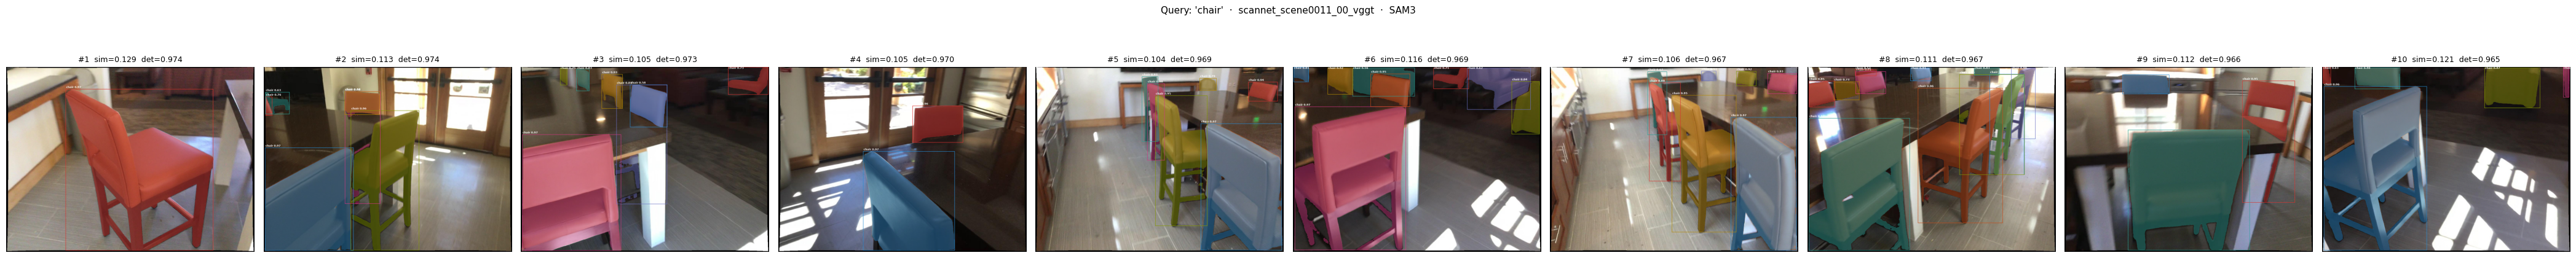

In [10]:
# ── 2D results: SAM mask overlays + boxes (same helper as Pipeline.ipynb) ─────
PALETTE = [
    (220, 50, 47), (38, 139, 210), (42, 161, 152), (133, 153, 0),
    (211, 54, 130), (181, 137, 0), (108, 113, 196), (203, 75, 22),
]
MASK_ALPHA = 110


def annotate_image(img, masks, boxes, scores, label):
    canvas = img.convert("RGBA")
    for i, mask in enumerate(masks or []):
        color = PALETTE[i % len(PALETTE)]
        mask_np = mask.cpu().numpy().astype(np.uint8)
        overlay = np.zeros((*mask_np.shape, 4), dtype=np.uint8)
        overlay[mask_np > 0] = [*color, MASK_ALPHA]
        canvas = Image.alpha_composite(canvas, Image.fromarray(overlay, "RGBA"))
    draw = ImageDraw.Draw(canvas)
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", size=14)
    except OSError:
        font = ImageFont.load_default()
    for i, (score, box) in enumerate(zip(scores, boxes)):
        color = PALETTE[i % len(PALETTE)]
        x0, y0, x1, y1 = [int(v) for v in box.tolist()]
        draw.rectangle([x0, y0, x1, y1], outline=(*color, 255), width=2)
        draw.text((x0 + 3, max(y0 - 18, 0)), f"{label[:12]} {float(score):.2f}",
                  fill=(255, 255, 255, 255), font=font)
    return canvas.convert("RGB")


n = len(state.results)
fig, axes = plt.subplots(1, n, figsize=(n * 4.2, 4.5), squeeze=False)
for rank, (ax, hit) in enumerate(zip(axes[0], state.results), start=1):
    annotated = annotate_image(Image.open(hit.path).convert("RGB"),
                               hit.masks, hit.boxes, hit.scores, QUERY)
    ax.imshow(np.array(annotated))
    ax.set_title(f"#{rank}  sim={hit.similarity_score:.3f}  det={hit.detection_score:.3f}",
                 fontsize=9)
    ax.axis("off")
plt.suptitle(f"Query: '{QUERY}'  ·  {COLLECTION}  ·  SAM3", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 3D result

`build_scene_cloud(fs, ...)` reconstructs the scene; `state.projected` holds
the localised object(s) — one fused object in `cluster_single` mode, one per spatial
cluster in `cluster_instances` mode (largest / most multi-frame consensus first). k3d
shows the scene cloud plus each object's points and 3D box in its own colour.

In [11]:
from src.utils.geometry import build_scene_cloud, aabb_corners

SCENE_N_FRAMES = 250   # full frames back-projected for the background cloud
VOXEL          = 0.02  # metres — downsample grid for both clouds

OBJ_COLORS = [0xff0000, 0x00a2ff, 0xffa500, 0xd633ff,
              0x00c853, 0xffe000, 0x8d6e63, 0x00bfa5]
EDGES = np.array([[0,1],[1,2],[2,3],[3,0],[4,5],[5,6],[6,7],[7,4],
                  [0,4],[1,5],[2,6],[3,7]], dtype=np.uint32)


def pack_rgb(colors):
    """Pack a uint8 (N, 3) RGB array into k3d's uint32 0xRRGGBB colours."""
    c = np.asarray(colors, dtype=np.uint32)
    return (c[:, 0] << 16) | (c[:, 1] << 8) | c[:, 2]


# Background scene cloud (reusable helper — same back-projection as the object).
scene_pts, scene_col = build_scene_cloud(fs, n_frames=SCENE_N_FRAMES, voxel=VOXEL)
print(f"Scene cloud: {len(scene_pts):,} points")
print(f"Objects    : {len(state.projected)}  (most multi-frame consensus first)")

plot = k3d.plot(grid_visible=False, camera_auto_fit=True)
plot += k3d.points(
    scene_pts.astype(np.float32),
    colors=pack_rgb(scene_col) if scene_col is not None else None,
    point_size=VOXEL, shader="flat", name="scene",
)

# One colour per projected object: point cloud + its 3D box.
for i, obj in enumerate(state.projected):
    color = OBJ_COLORS[i % len(OBJ_COLORS)]
    print(f"  {obj.id:<7} #{color:06x}  {len(obj.points):>7,} points  ·  "
          f"bbox min={np.round(obj.bbox[0], 2)}  max={np.round(obj.bbox[1], 2)}"
          if obj.bbox is not None else f"  {obj.id}: no bbox")
    plot += k3d.points(
        obj.points.astype(np.float32),
        color=color, point_size=VOXEL * 1.5, shader="flat",
        name=f"{obj.id}: {QUERY}",
    )
    if obj.bbox is not None:
        corners = aabb_corners(obj.bbox).astype(np.float32)
        plot += k3d.lines(corners, indices=EDGES, indices_type="segment",
                          color=color, width=0.01, name=f"bbox {obj.id}")
plot.display()

Scene cloud: 28,913 points
Objects    : 9  (most multi-frame consensus first)
  obj-0   #ff0000      283 points  ·  bbox min=[ 0.16 -0.41  0.84]  max=[ 0.32 -0.14  1.02]
  obj-1   #00a2ff      270 points  ·  bbox min=[-0.27 -0.11  0.34]  max=[-0.14  0.15  0.58]
  obj-2   #ffa500      264 points  ·  bbox min=[ 0.72 -0.53  1.04]  max=[ 0.86 -0.24  1.22]
  obj-3   #d633ff      248 points  ·  bbox min=[-0.06 -0.33  0.74]  max=[ 0.09 -0.06  0.91]
  obj-4   #00c853      189 points  ·  bbox min=[-0.24 -0.26  0.63]  max=[-0.11  0.    0.78]
  obj-5   #ffe000      159 points  ·  bbox min=[ 0.41 -0.47  0.95]  max=[ 0.55 -0.22  1.13]
  obj-6   #8d6e63      129 points  ·  bbox min=[ 0.65 -0.3   0.64]  max=[ 0.76 -0.14  0.84]
  obj-7   #00bfa5       88 points  ·  bbox min=[ 0.01 -0.09  0.27]  max=[0.13 0.05 0.35]
  obj-8   #ff0000       54 points  ·  bbox min=[ 0.26 -0.16  0.38]  max=[ 0.38 -0.07  0.48]


/usr/prakt/s0034/AppliedFoundationModels/.venv/lib/python3.12/site-packages/traittypes/traittypes.py:98: UserWarning: Given trait value dtype "uint32" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()